In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

In [2]:
with open("/workspace/deception-detection/results/by_layer_harm_pressure_choice_control_10000_lr__repe_honesty__plain__llama-70b-3.3__20260108_164517/scores_by_layer.json", "r") as f:
    scores = json.load(f)

In [3]:
scores.keys()

dict_keys(['repe_honesty__plain_val', 'harm_pressure_choice__test', 'alpaca__plain'])

In [4]:
control_thresholds = []
for layer in scores["alpaca__plain"].keys():
    layer_scores_per_token = scores["alpaca__plain"][layer]["scores"]
    layer_scores_per_prompt = [np.mean(prompt_scores) for prompt_scores in layer_scores_per_token]
    layer_threshold = np.percentile(layer_scores_per_prompt, 99)
    control_thresholds.append(layer_threshold)

In [5]:
layer_wise_data_hp = {}
for layer in scores["harm_pressure_choice__test"].keys():
    layer_scores_per_token = scores["harm_pressure_choice__test"][layer]["scores"]
    layer_scores_per_prompt = [np.mean(prompt_scores) for prompt_scores in layer_scores_per_token]
    threshold = control_thresholds[int(layer)]
    layer_predictions = ["DECEPTIVE" if score > threshold else "HONEST" for score in layer_scores_per_prompt]
    layer_labels = scores["harm_pressure_choice__test"][layer]["labels"]
    layer_wise_data_hp[layer] = {
        "predictions": layer_predictions,
        "labels": layer_labels,
    }

In [6]:
layerwise_predictions = []
layerwise_labels = []

for layer in layer_wise_data_hp.keys():
    layerwise_predictions.append(layer_wise_data_hp[layer]["predictions"])
    layerwise_labels.append(layer_wise_data_hp[layer]["labels"])
    
print(len(layerwise_predictions), len(layerwise_labels))

80 80


In [7]:
layerwise_errors = []
for layer_preds, layer_labels in zip(layerwise_predictions, layerwise_labels):
    layer_errors = []
    for pred, label in zip(layer_preds, layer_labels):
        layer_errors.append(int(pred != label))
    layerwise_errors.append(layer_errors)
    
len(layerwise_errors)

80

#### NAND
- NAND of errors: If I combine these two classifiers, how often do they not both fail on the same example?
- High NAND → good candidates for ensembling
- Low NAND → little benefit from combining

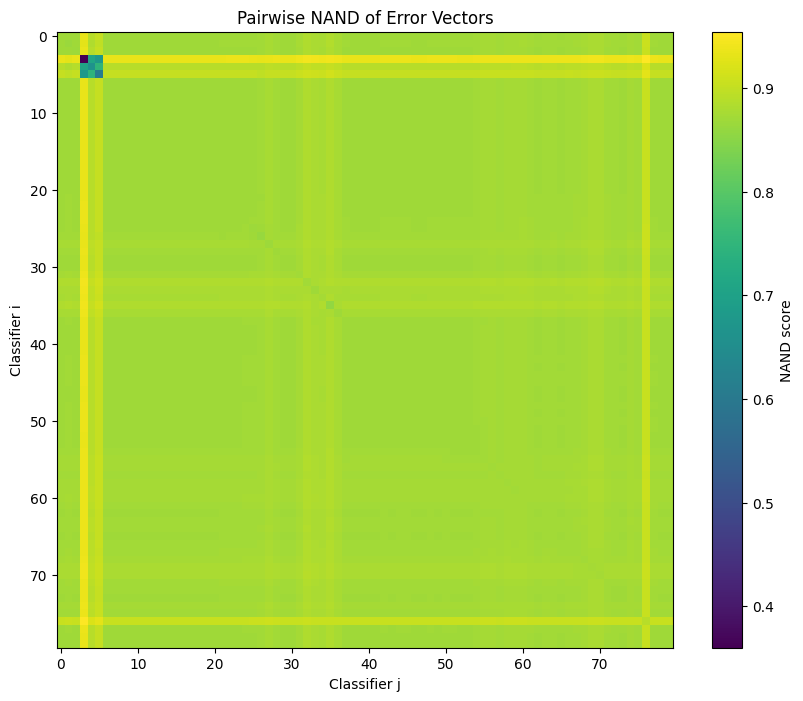

In [8]:
E = np.array(layerwise_errors)           # shape: (M, n)
M, n = E.shape

nand_matrix = np.zeros((M, M))

for i in range(M):
    for j in range(M):
        both_wrong = np.logical_and(E[i], E[j])
        nand_matrix[i, j] = 1.0 - both_wrong.mean()
        
plt.figure(figsize=(10, 8))
plt.imshow(nand_matrix, cmap="viridis")
plt.colorbar(label="NAND score")
plt.xlabel("Classifier j")
plt.ylabel("Classifier i")
plt.title("Pairwise NAND of Error Vectors")
plt.show()


#### Double Fault
- Double Fault: How often are both classifiers wrong on the same example?
- Lower DF -> Better for ensembling
- Higher DF -> Not so good for ensembling

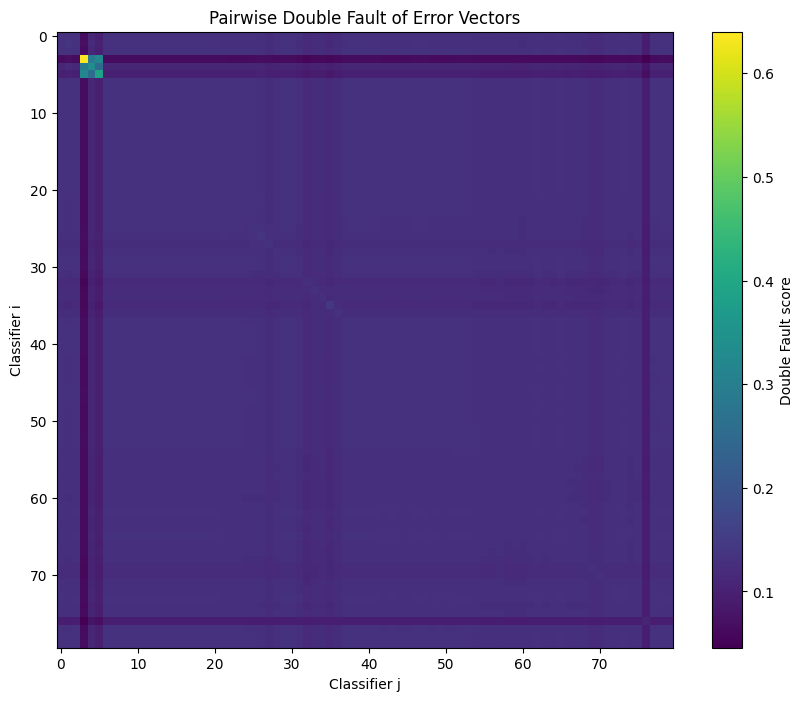

In [9]:
double_fault = (E[:, None, :] & E[None, :, :]).mean(axis=2)
plt.figure(figsize=(10, 8))
plt.imshow(double_fault, cmap="viridis")
plt.colorbar(label="Double Fault score")
plt.xlabel("Classifier j")
plt.ylabel("Classifier i")
plt.title("Pairwise Double Fault of Error Vectors")
plt.show()

#### Conditional Double Fault
- Conditional DF: If classifier i is wrong, how often is j also wrong?
- Low CDF -> j often fixes i’s mistakes
- High CDF -> j fails whenever i fails

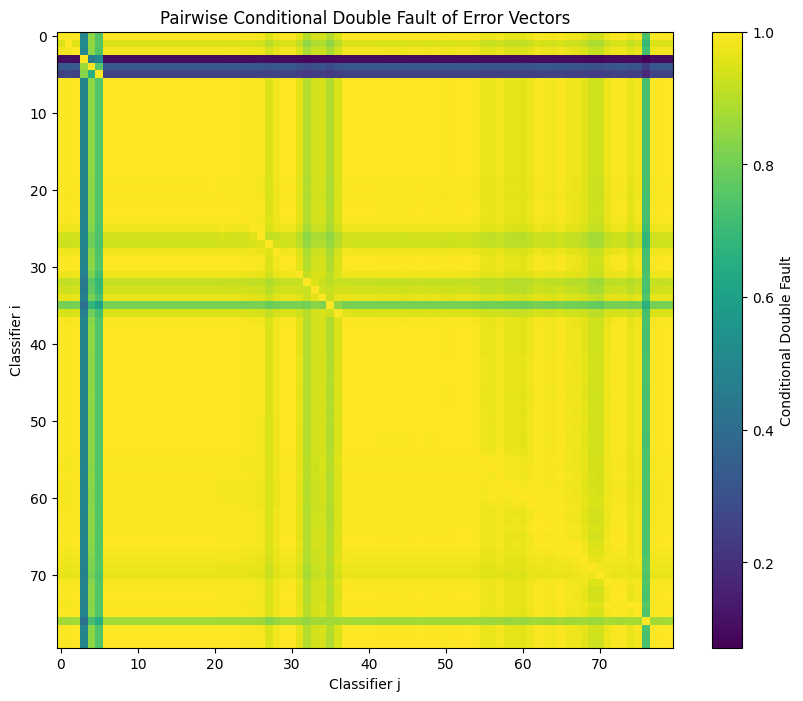

In [10]:
cond_df = np.zeros((M, M))
for i in range(M):
    mask = E[i] == 1
    if mask.sum() > 0:
        cond_df[i] = E[:, mask].mean(axis=1)
        
plt.figure(figsize=(10, 8))
plt.imshow(cond_df, cmap="viridis")
plt.colorbar(label="Conditional Double Fault")
plt.xlabel("Classifier j")
plt.ylabel("Classifier i")
plt.title("Pairwise Conditional Double Fault of Error Vectors")
plt.show()